Step 1: Imports done
Step 2: Data loaded
Shape: (100000, 54)
Step 3: Columns cleaned
Step 4: Missing values handled
Step 5: Encoding done
Step 6: Features ready
X shape: (100000, 72)
Step 7: Scaling done
Step 8: Split done
Training started...
Training finished ✅

MODEL RESULTS
RMSE: 639.93932911038
R2: 0.9583825031615387


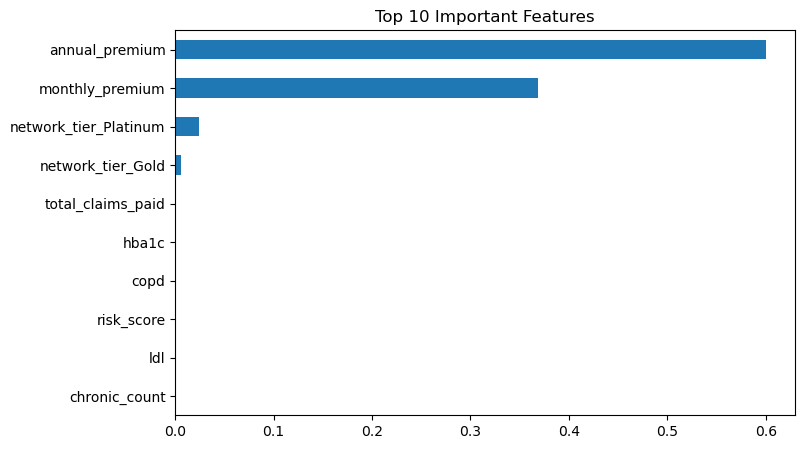

✅ Model, Scaler, Columns saved successfully!


In [1]:
# =========================================
# 1. IMPORTS
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor

import pickle

print("Step 1: Imports done")

# =========================================
# 2. LOAD DATA
# =========================================
df = pd.read_csv("insurance.csv")
print("Step 2: Data loaded")
print("Shape:", df.shape)

# =========================================
# 3. CLEANING
# =========================================
df = df.drop(columns=['person_id'], errors='ignore')
print("Step 3: Columns cleaned")

# =========================================
# 4. HANDLE MISSING VALUES (IMPORTANT)
# =========================================
df = df.fillna(0)
print("Step 4: Missing values handled")

# =========================================
# 5. ENCODING
# =========================================
df = pd.get_dummies(df, drop_first=True)
print("Step 5: Encoding done")

# =========================================
# 6. DEFINE FEATURES & TARGET
# =========================================
target = "annual_medical_cost"

X = df.drop(target, axis=1)
y = df[target]

print("Step 6: Features ready")
print("X shape:", X.shape)

# =========================================
# 7. SCALING
# =========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Step 7: Scaling done")

# =========================================
# 8. TRAIN TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Step 8: Split done")

# =========================================
# 9. MODEL (FAST VERSION)
# =========================================
model = RandomForestRegressor(
    n_estimators=10,   # 🔥 small → fast
    max_depth=5,
    random_state=42
)

print("Training started...")
model.fit(X_train, y_train)
print("Training finished ✅")

# =========================================
# 10. EVALUATION
# =========================================
preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("\nMODEL RESULTS")
print("RMSE:", rmse)
print("R2:", r2)

# =========================================
# 11. FEATURE IMPORTANCE (TOP 10)
# =========================================
importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().tail(10).plot(kind='barh', figsize=(8,5))
plt.title("Top 10 Important Features")
plt.show()

# =========================================
# 12. SAVE FILES
# =========================================
pickle.dump(model, open("deployment/model.pkl", "wb"))
pickle.dump(scaler, open("deployment/scaler.pkl", "wb"))
pickle.dump(X.columns.tolist(), open("deployment/columns.pkl", "wb"))

print("✅ Model, Scaler, Columns saved successfully!")